# 0.環境構築

In [1]:
#%pip install -q seaborn

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import japanize_matplotlib
import seaborn as sns

%matplotlib inline

In [49]:
#-----------------------------------------------
#grapfvizの設定
#-----------------------------------------------

import os
import sys

# Graphvizの bin フォルダのパスを指定 (環境に合わせて変更してください)
graphviz_path = r"C:\Program Files\Graphviz\bin"

# PATHに一時的に追加
os.environ["PATH"] += os.pathsep + graphviz_path

# この後に graphviz や pydot を呼び出す
import graphviz

# 1.データ分布のベイズ推論

## 1-1. データ生成

In [4]:
dt = sns.load_dataset('iris')
dt.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
X = dt.query('species =="setosa"').sepal_length.values
X

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. ])

<Axes: ylabel='Count'>

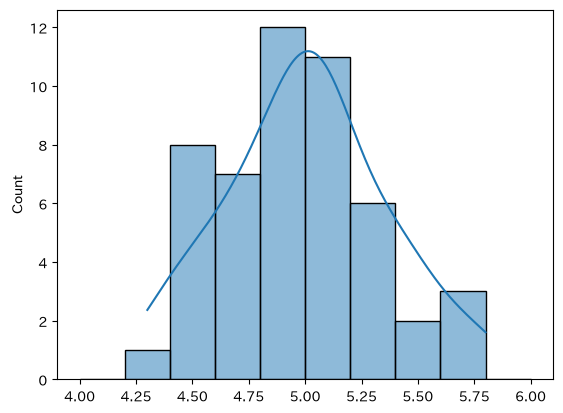

In [6]:
#-----------------------------------------------
#分布の確認
#-----------------------------------------------
bins = np.arange(4, 6.2, 0.2)
sns.histplot(X, kde=True, bins=bins)

## 1-2. 確率モデルの定義

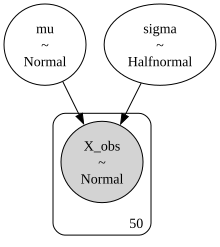

In [7]:
model11 = pm.Model()

with model11:
    mu = pm.Normal('mu', mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal('sigma', sigma=10.0)
    X_obs = pm.Normal('X_obs', mu=mu, sigma=sigma, observed=X)
    
g = pm.model_to_graphviz(model11)
display(g)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.
Sampling: [X_obs, mu, sigma]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,5.006,0.05,4.9,5.1,3718,2402,1.00,0.00082,0.00095
sigma,0.362,0.039,0.31,0.43,3436,2412,1.00,0.00066,0.00064


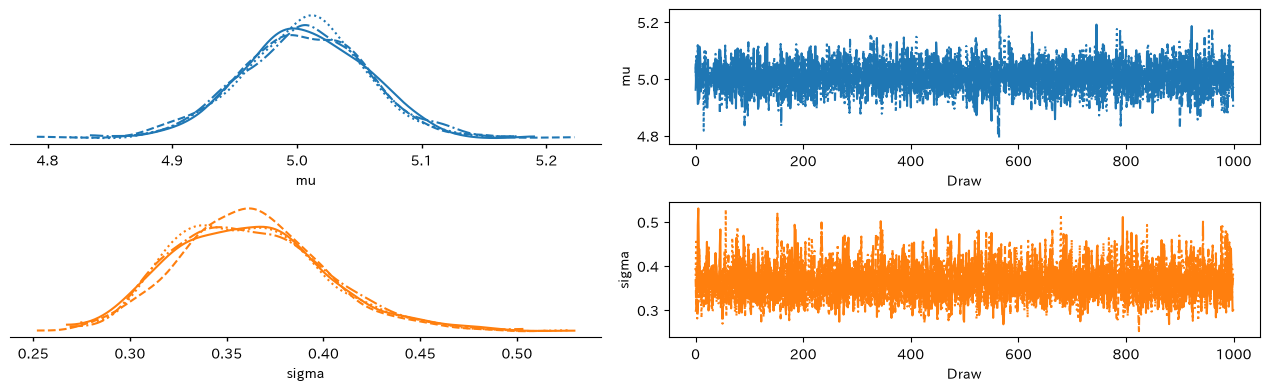

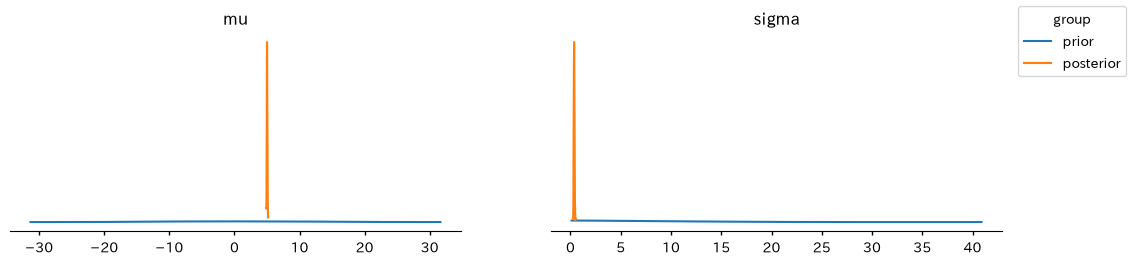

In [8]:
#-----------------------------------------------
#MCMCの実行, trace確認
#-----------------------------------------------
with model11:
    idata1 = pm.sample(random_seed=42)
    idata1['prior'] = pm.sample_prior_predictive(random_seed=42).prior

#traca_plot
azp.plot_trace_dist(idata1)
plt.tight_layout();

#prior, posterior plot
azp.plot_prior_posterior(idata1)

#summary
summary = azs.summary(idata1)
display(summary)

# 2. 線形回帰のベイズ推論

## 2-1. データ準備

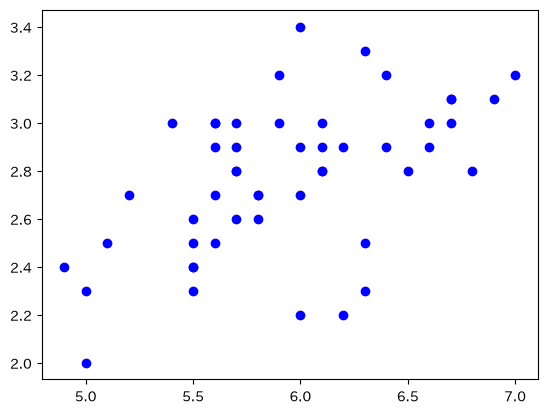

In [9]:
import matplotlib.pyplot as plt

df = sns.load_dataset('iris')
df1 = df.query('species=="versicolor"')

X = df1['sepal_length']
Y = df1['sepal_width']

plt.scatter(X, Y, label="xxx", c='b', marker='o')

## 2-2. モデル定義

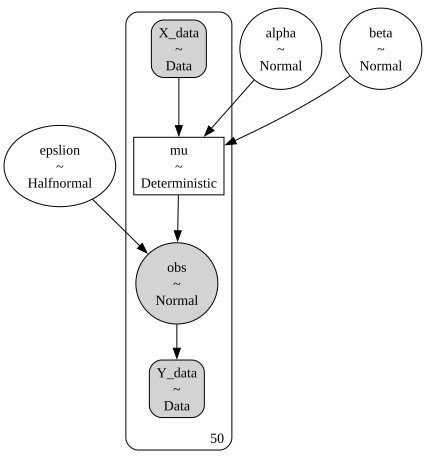

In [10]:
#---------------------------------------------------------------
#モデル定義.1
#---------------------------------------------------------------
# model1 = pm.Model()

# with model1:
#     alpha = pm.Normal('alpha', mu=0, sigma=10)
#     beta = pm.Normal('beta', mu=0, sigma=10)
    
#     #平均値muの計算（y = ax + b + ε）
#     mu = alpha * X + beta
    
#     #誤差の計算
#     epslion = pm.HalfNormal('epslion', sigma=1)
    
#     #観測値を持つ確率変数はY_obsとして定義
#     Y_obs = pm.Normal('Y_obs', mu=mu, sigma=epslion, observed=Y)
    
# g = pm.model_to_graphviz(model1)
# display(g)

#---------------------------------------------------------------
#モデル定義.2
#---------------------------------------------------------------
model2 = pm.Model()

with model2:
    # X, Yの観測値をConstantDataとして定義（PyMC>v6ではDataメソッドを使用）
    # https://www.pymc.io/projects/docs/en/stable/api/data.html
    X_data = pm.Data('X_data', X)
    Y_data = pm.Data('Y_data', Y)
    
    #確率変数alpha, betaの定義（1次関数の傾きと切片）
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10)
    
    #平均値muの計算
    mu = pm.Deterministic('mu', alpha * X_data + beta)
    
    #誤差
    epslion = pm.HalfNormal('epslion', sigma=1)
    
    #観測値はobsで定義
    obs = pm.Normal('obs', mu=mu, sigma=epslion, observed=Y_data)
    
g = pm.model_to_graphviz(model2)
display(g)

## 2-3. MCMCサンプリング

In [11]:
with model2:
    idata2 = pm.sample(random_seed=42)
    idata2['prior'] = pm.sample_prior_predictive(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, epslion]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.
There were 11 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [alpha, beta, epslion, obs]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.322,0.08,0.2,0.45,733,860,1.01,0.003,0.0017
beta,0.86,0.47,0.11,1.6,727,900,1.01,0.018,0.01
epslion,0.277,0.031,0.23,0.33,427,224,1.01,0.0013,0.0011


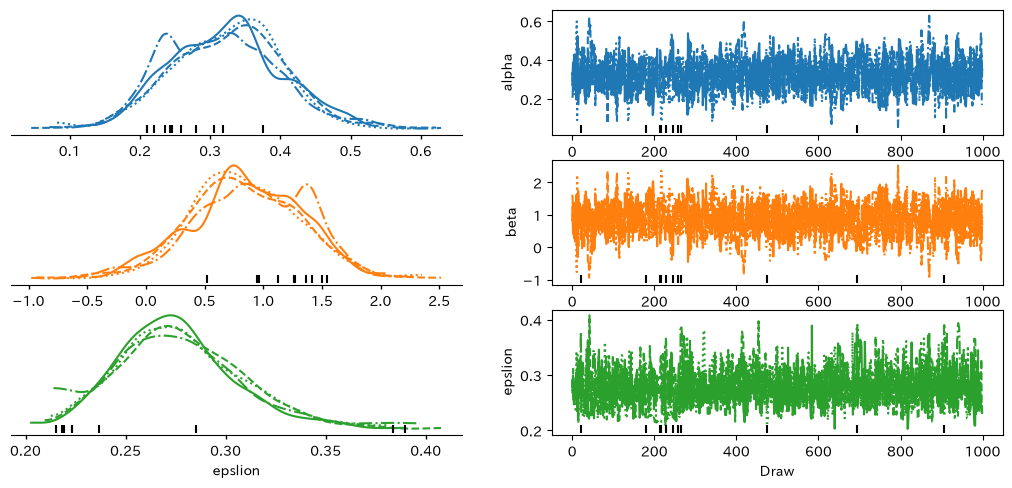

In [12]:
#---------------------------------------------------------------
#トレースプロット
#結果から、alpha:0.3, beta:0.86, epsilon:0.28
#---------------------------------------------------------------
#結果の表示
display(azs.summary(idata2, var_names=["alpha", "beta", "epslion"]))
ax = azp.plot_trace_dist(idata2, var_names=["alpha", "beta", "epslion"], group="posterior")
ax.show()

## 2-4. 回帰直線のプロット

[4.8 7.1] (2,)
(4000, 1) (4000, 1)
[[2.53554424 3.16484078]
 [2.45071366 3.23598686]
 [2.27286559 3.16498793]
 ...
 [2.30513382 3.31581405]
 [2.26843345 3.25026191]
 [2.4828482  3.23011778]] (4000, 2)


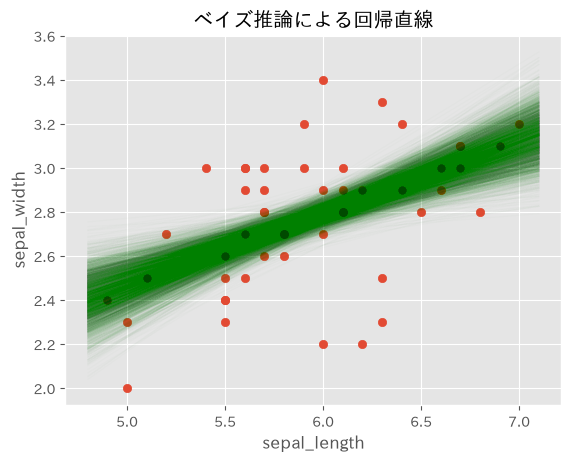

In [ ]:
#xの2点をNumPy配列にする
x_values = np.array([X.min()-0.1, X.max()+0.1])
print(x_values, x_values.shape)

#サンプリング結果からalpha, betaを抽出し加工
alphas2 = azb.extract(idata2, group='posterior', var_names="alpha").values.reshape(-1,1) #1行にする(2次元配列にする)
betas2 = azb.extract(idata2, group='posterior', var_names="beta").values.reshape(-1,1) #1行にする(2次元配列にする)
print(alphas2.shape, betas2.shape)

#予測値の計算
y_preds = x_values * alphas2 + betas2
print(y_preds, y_preds.shape)

import japanize_matplotlib
# Set ggplot style
plt.style.use('ggplot')

for y_pred in y_preds:
    plt.plot(x_values, y_pred, lw=1, alpha=0.01, c='g')
plt.scatter(X, Y)
plt.title('ベイズ推論による回帰直線')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.show()

"""
<NumPyブロードキャスト機能に関する補足>
1. (2,)のような配列は先頭に1が入り自動的に2次元配列になる。ex. (2,)→(1,2)
2. (1,2)もしくは(2,1)のようにサイズが1のものは計算時に計算対象となる配列に合わせて拡張される。ex.(2,1)*(2,4)→(2,4)*(2,4)

(2, 1) の配列            (2, 4) の配列
   [ [ 10 ],               [ [ 1,  2,  3,  4 ],
     [ 20 ] ]                [ 5,  6,  7,  8 ] ]

          ↓  (2, 1) 側だけが横に引き伸ばされる

  (2, 4) に拡張            (2, 4) のまま
   [ [ 10, 10, 10, 10 ],   [ [ 1,  2,  3,  4 ],
     [ 20, 20, 20, 20 ] ]    [ 5,  6,  7,  8 ] ]

          ↓ 要素ごとに掛け算

  【結果: shape (2, 4)】
   [ [ 10, 20, 30, 40 ],
     [ 100, 120, 140, 160 ] ]
"""

### 参考：ブロードキャスト機能
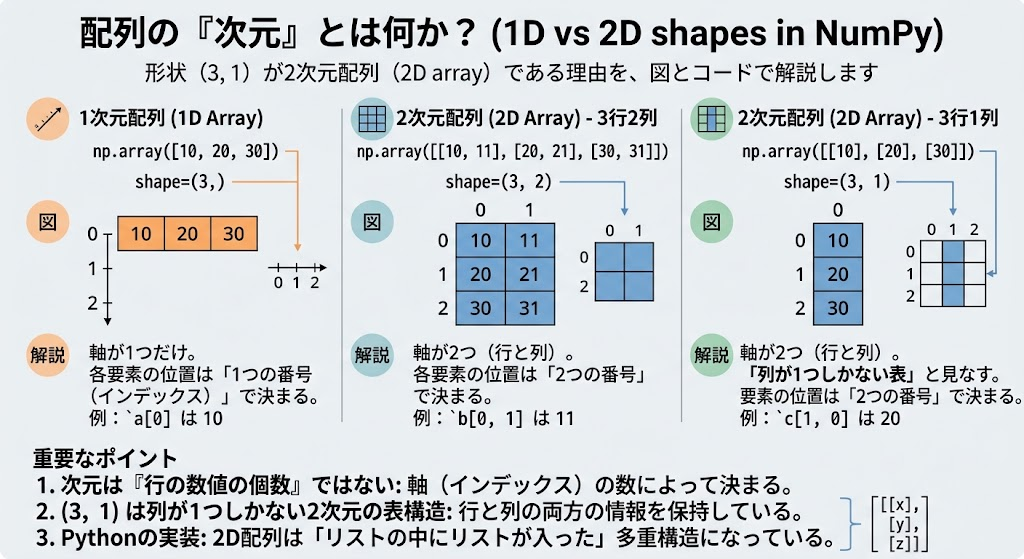

# 3. 階層ベイズモデル
 - 参考：bambi（簡易ベイズモデル）：https://bambinos.github.io/bambi/notebooks/

## 階層ベイズモデルの背景とメリット

- データは、個人・グループ・条件ごとに異なるばらつきを持つことが多く、単一の平均パラメータでは説明しきれない。
- 階層ベイズモデルでは、全体の分布を表す共通パラメータと、各グループごとの個別パラメータを同時に扱うことで、データの構造をより自然に表現できる。
- これにより、少ないサンプル数のグループでも、他のグループの情報を共有して安定した推定が可能になる。
- 観測誤差や個体差、不確実性を一貫してモデル化できるため、予測や意思決定の信頼性が高まる。
- 既存の単純な回帰や平均値モデルよりも、現実のデータ生成過程に近い表現ができるのが大きな利点である。

## 3-1. データの準備

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import pymc as pm

g++ not available, if using conda: `conda install gxx`


In [ ]:
df =sns.load_dataset('iris')

#種別にデータセットを分ける
df0 = df.query('species=="setosa"')
df1 = df.query('species=="versicolor"')
df2 = df.query('species=="virginica"')

#乱数により3個のインデックスを作成
import random
random.seed(42)
indexes = range(len(df1))
sample_indexes = random.sample(indexes, 3)
#print(indexes ,sample_indexes)

df0_sel = df0.iloc[sample_indexes]
df1_sel = df1.iloc[sample_indexes]
df2_sel = df2.iloc[sample_indexes]

df_sel = pd.concat([df0_sel, df1_sel, df2_sel], axis=0).reset_index(drop=True)
display(df_sel)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.0,3.5,1.3,0.3,setosa
1,5.0,3.4,1.5,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,5.5,2.6,4.4,1.2,versicolor
4,4.9,2.4,3.3,1.0,versicolor
5,6.4,3.2,4.5,1.5,versicolor
6,6.7,3.1,5.6,2.4,virginica
7,7.3,2.9,6.3,1.8,virginica
8,5.8,2.7,5.1,1.9,virginica


findfont: Failed to find font weight bold for IPAexGothic, now using 400.


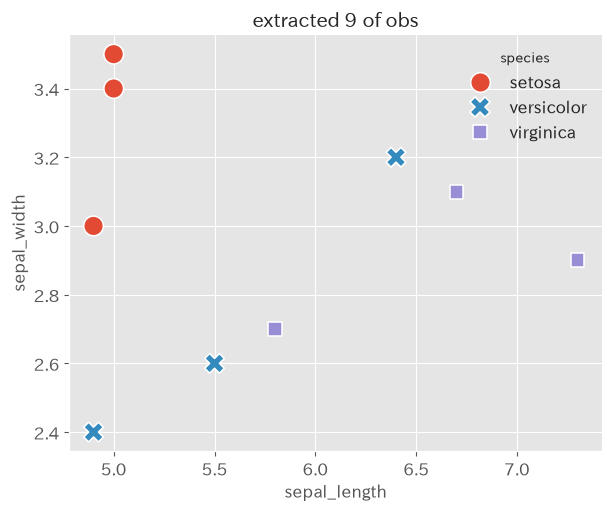

In [30]:
plt.style.use('ggplot')

sns.scatterplot(
    x='sepal_length',
    y='sepal_width',
    hue='species',
    style='species',
    data=df_sel, s=200
)

plt.title('extracted 9 of obs')
plt.show()

In [90]:
"""
alphaとbetaは種によって異なるという仮定が前提
"""
X = df_sel.sepal_width.values
Y = df_sel.sepal_length.values
species = df_sel.species
cl = pd.Categorical(species).codes
print(X)
print(Y)
print(species)
print(cl)

[3.5 3.4 3.  2.6 2.4 3.2 3.1 2.9 2.7]
[5.  5.  4.9 5.5 4.9 6.4 6.7 7.3 5.8]
0        setosa
1        setosa
2        setosa
3    versicolor
4    versicolor
5    versicolor
6     virginica
7     virginica
8     virginica
Name: species, dtype: str
[0 0 0 1 1 1 2 2 2]


## 3-2. 確率モデルの定義

In [91]:
model11 = pm.Model()

with model11:
    #X,YのデータをDataとして定義
    X_data = pm.Data('X_data', X)
    Y_data = pm.Data('Y_data', Y)
    
    #クラス変数定義
    cl_data = pm.Data('cl_data', cl)
    
    #確率変数alphaの定義
    a_mu = pm.Normal('a_mu', mu=0, sigma=10)
    a_sigma = pm.HalfNormal('a_sigma', sigma=10.0)
    alpha = pm.Normal('alpha', mu=a_mu, sigma=a_sigma, shape=(3,))
    
    #確率変数の定義
    b_mu = pm.Normal('b_mu', mu=0, sigma=10)
    b_sigma = pm.HalfNormal('b_sigma', sigma=10.0)
    beta = pm.Normal('beta', mu=b_mu, sigma=b_sigma, shape=(3,))
    
    #誤差epsilonの定義
    epslion = pm.HalfNormal('epsilon', sigma=1.0)
    
    #muの値は cl_data によりindexを切り替えて計算
    #「この途中計算の結果は後でグラフに描いたり統計量を見たいから保存しておいて！」 と明示的に指示するためのツールが pm.Deterministic です。
    mu = pm.Deterministic('mu', X_data * alpha[cl_data] + beta[cl_data])
    
    #確率モデルの定義
    obs = pm.Normal('obs', mu=mu, sigma=epslion, observed=Y_data)

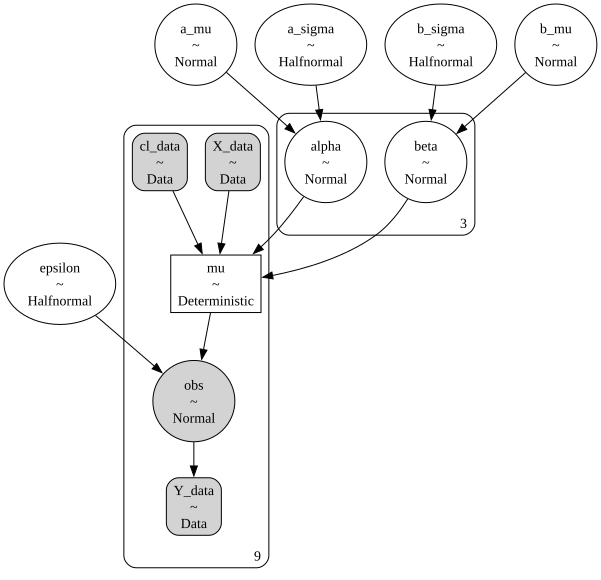

In [92]:
g = pm.model_to_graphviz(model11)
display(g)

## 3-3. MCMCサンプリング

In [93]:
with model11:
    idata1 = pm.sample(random_seed=42, target_accept=0.998)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a_mu, a_sigma, alpha, b_mu, b_sigma, beta, epsilon]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 62 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


C:\Users\kzapp\AppData\Local\Temp\ipykernel_38940\2423235390.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[0],1.07,0.9,-0.29,2.4,759,920,1.01,0.033,0.046
alpha[1],1.56,0.81,0.28,2.8,915,913,1.00,0.027,0.029
alpha[2],1.67,1,0.22,3.1,765,935,1.01,0.037,0.059
beta[0],1.5,3,-2.9,5.9,769,901,1.01,0.11,0.15
beta[1],1.3,2.2,-2,4.9,905,922,1.00,0.074,0.08
beta[2],1.7,2.9,-2.5,5.9,777,1009,1.01,0.11,0.17


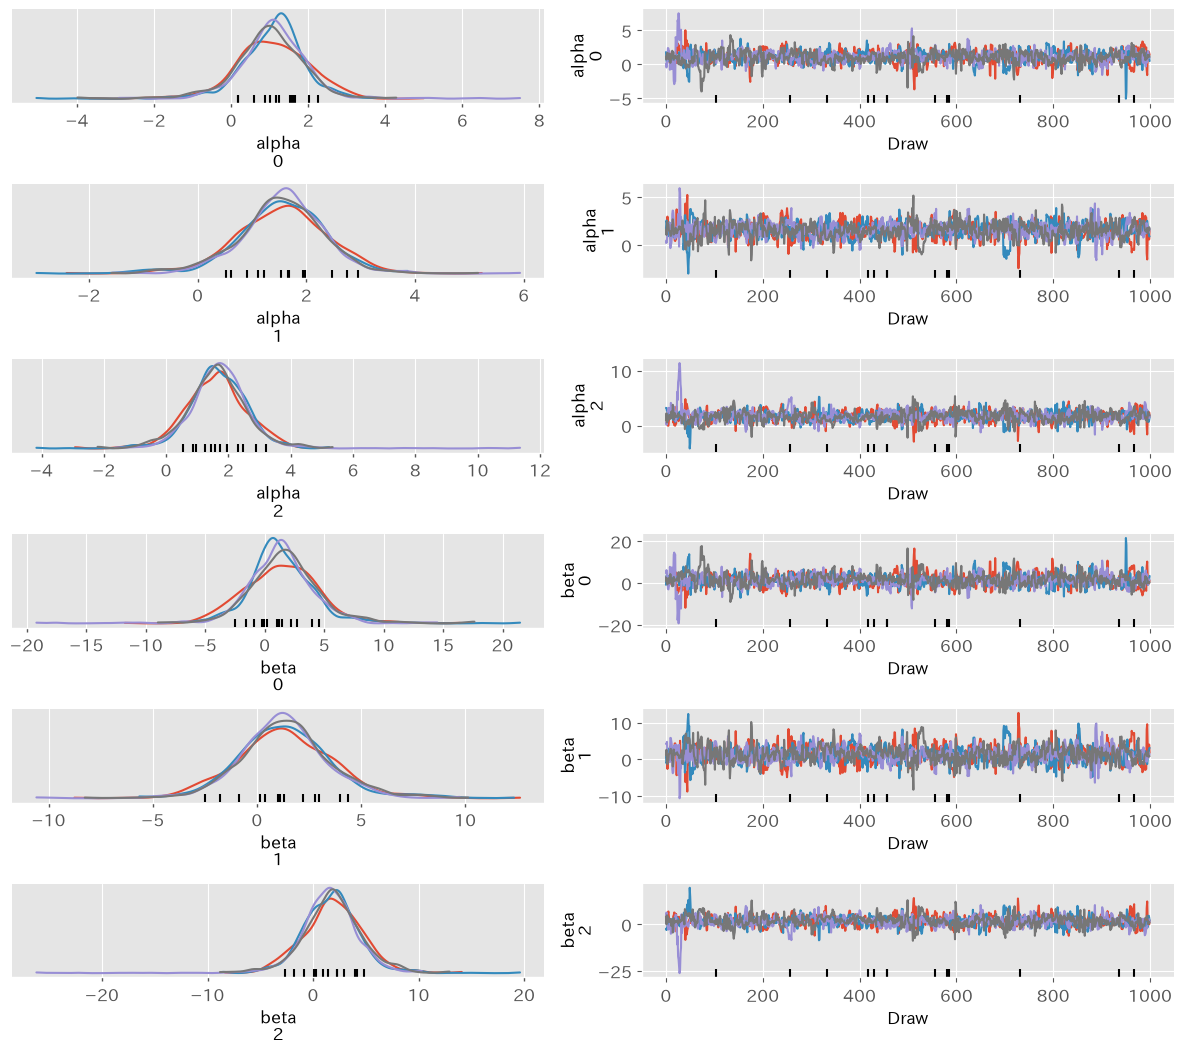

In [105]:
azp.plot_trace_dist(idata1, var_names=["alpha", "beta"], compact=False)
plt.tight_layout();

azs.summary(idata1, var_names=['alpha', 'beta'])

### 参考：a_mu, b_muの分布

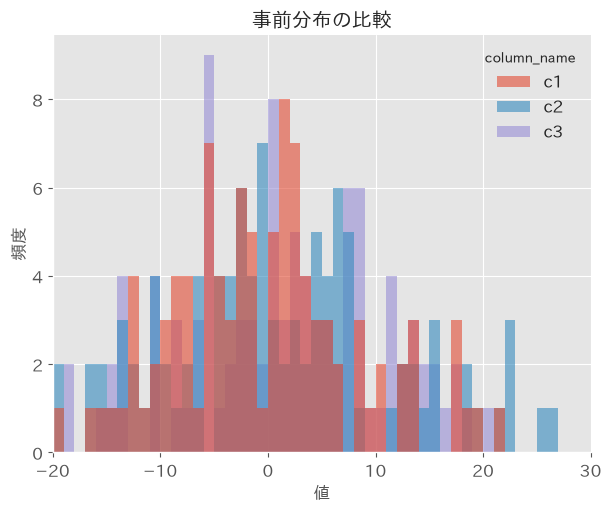

In [79]:
# 事前分布のサンプルを生成
pars = pm.draw(
    pm.Normal.dist(mu=0, sigma=10, shape=(100, 3)),
    random_seed=42
)

# DataFrame化
df_pars = pd.DataFrame(pars, columns=["c1", "c2", "c3"])

# 縦長に変換
df_pars_long = df_pars.melt(var_name="column_name", value_name="value")

# 可視化
bins = np.arange(-20, 30, 1)
sns.histplot(
    data=df_pars_long,
    x="value",
    hue="column_name",
    bins=bins,
    multiple="layer",
    alpha=0.6,
    edgecolor="none"
)

plt.style.use('ggplot')
plt.title("事前分布の比較")
plt.xlabel("値")
plt.ylabel("頻度")
plt.xlim(-20, 30)
plt.show()